In [ ]:
# Importiamo tutti i pacchetti necessari
import numpy as np 
import matplotlib.pyplot as plt
import rebound  
import datetime

from PIL import Image

### 6) Analisi degli integratori (GAS)

Vediamo di fare un setup semplice, gas in box periodiche (+ non periodiche?) e di vedere come cambia 



In [ ]:
boxL = 10
sim = rebound.Simulation()
sim.widget(port=1247,size=(300,300))
sim.configure_box(boxL)
sim.boundary = "periodic"
# sim.gravity = "tree"
sim.integrator = "leapfrog"
sim.dt = 0.01
sim.integrator = "ias15"
# sim.integrator = "whfast"
# sim.ri_ias15.min_dt = 1e-4
# sim.ri_whfast.corrector = 17
# sim.ri_whfast.corrector2 = 0
sim.collision = "none"
sim.softening = 1
sim.opening_angle2 = 1.5
np.random.seed(0)
print(sim.dt)
M = 100
N = 100
m = 100
T = 1000
V = 0.01
for i in range(N):
    x = np.random.uniform(-boxL,boxL)/2
    y = np.random.uniform(-boxL,boxL)/2
    z = np.random.uniform(-boxL,boxL)/2
    vx = np.random.uniform(-V,V)
    vy = np.random.uniform(-V,V)
    vz = np.random.uniform(-V,V)
    sim.add(m=M/N,x=x,y=y,z=z,vx=vx,vy=vy,vz=vz)
energy = np.array([])
def heartbeat(sim_pointer):
    global energy
    energy = np.append(energy,(sim.energy()))

sim.heartbeat = heartbeat

REBOUND Webserver listening on http://localhost:1247 ...


0.01


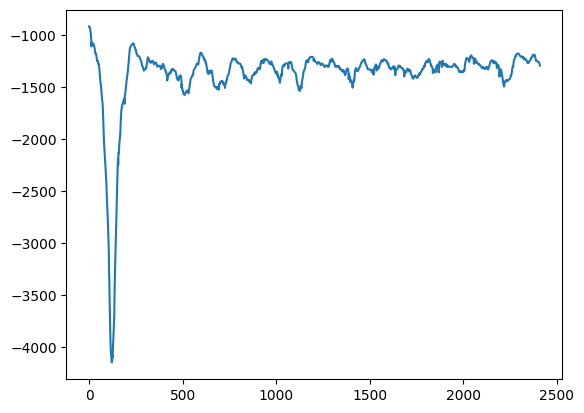

In [ ]:
sim.integrate(T)
fig, ax = plt.subplots()
ax.plot(energy)